# 04. Weighted Loss

Since all the classes are weighted the same in traditional cross entropy loss, we're going to Implement weighted cross entropy loss so that underrepresented classes are detected better

## Load Data

In [1]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from src.model import ECGNet

# load
npz = np.load('../data/processed/beats_split.npz')
X_train = torch.tensor(npz['X_train']).unsqueeze(1)  # (N, 1, 360)
y_train = torch.tensor(npz['y_train'])
X_test  = torch.tensor(npz['X_test']).unsqueeze(1)
y_test  = torch.tensor(npz['y_test'])

print(X_train.shape, y_train.shape)
print(X_test.shape,  y_test.shape)

torch.Size([50995, 1, 360]) torch.Size([50995])
torch.Size([49687, 1, 360]) torch.Size([49687])


In [2]:
train_ds = TensorDataset(X_train, y_train)
test_ds  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 797
Test batches:  777


## Weighted Loss Implementation

In [3]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3, 4]),
    y=y_train.numpy()
)
print(weights)

[2.22486420e-01 1.08040254e+01 2.69244984e+00 2.46352657e+01
 1.27487500e+03]


## Training Loop

In [5]:
from torch import nn

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model     = ECGNet().to(device)
weight   = torch.tensor(weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f'Device: {device}')

Device: mps


In [6]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # 1. move to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # 2. zero gradients
        optimizer.zero_grad()
        # 3. forward pass
        y_pred = model(X_batch)
        # 4. compute loss
        loss = criterion(y_pred, y_batch)
        # 5. backward pass
        loss.backward()
        # 6. optimizer step
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)
    
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    

Epoch [1/10], Loss: 1.2725
Epoch [2/10], Loss: 1.1570
Epoch [3/10], Loss: 1.0811
Epoch [4/10], Loss: 0.9986
Epoch [5/10], Loss: 0.9611
Epoch [6/10], Loss: 0.9411
Epoch [7/10], Loss: 0.9147
Epoch [8/10], Loss: 0.9026
Epoch [9/10], Loss: 0.8790
Epoch [10/10], Loss: 0.8836


## Evaluate Predictions

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
from src.data_loader import CLASS_NAMES

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

              precision    recall  f1-score   support

           N       0.95      0.72      0.82     44235
           S       0.05      0.18      0.07      1837
           V       0.52      0.68      0.59      3220
           F       0.01      0.17      0.02       388
           Q       0.00      0.00      0.00         7

    accuracy                           0.69     49687
   macro avg       0.30      0.35      0.30     49687
weighted avg       0.88      0.69      0.77     49687



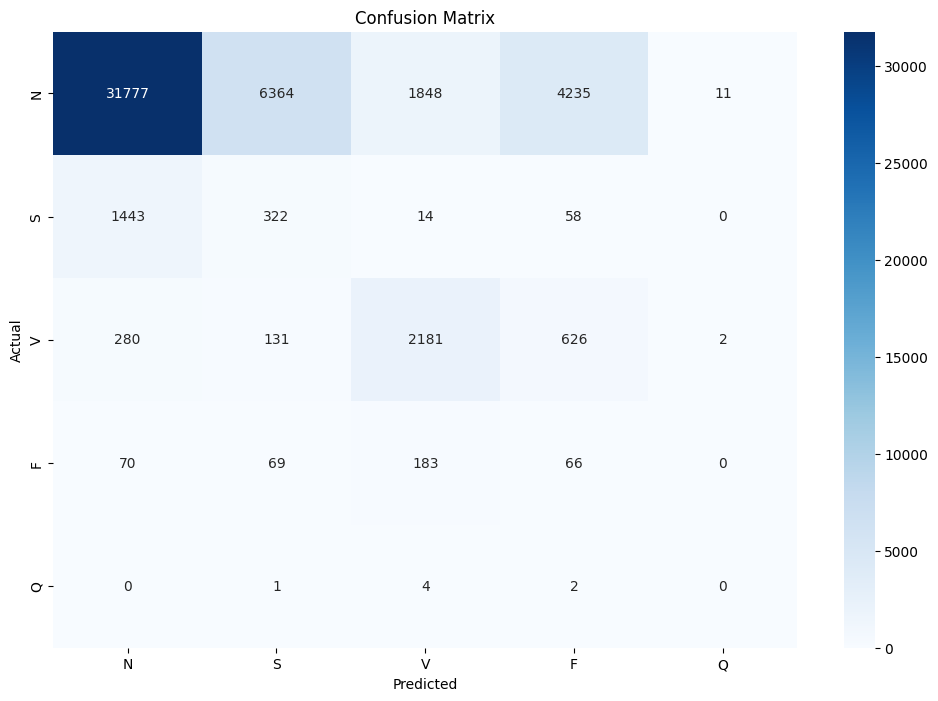

In [11]:
# PLot the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('../results/weighted_loss_cm_raw.png', dpi=150, bbox_inches='tight')
plt.show()



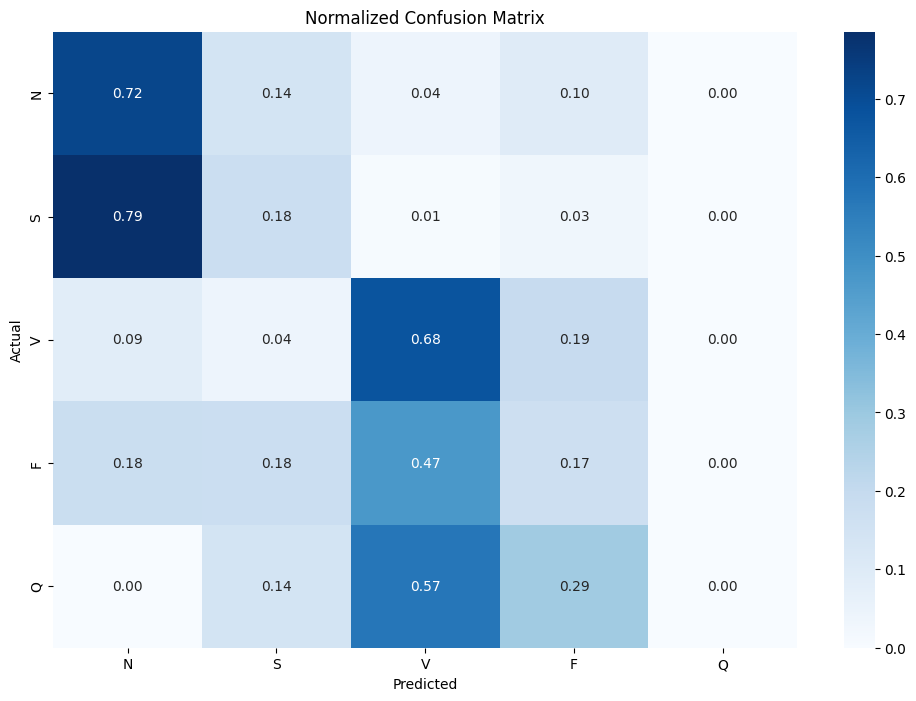

In [12]:
# PLot normalized confusion matrix

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(12, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix')
plt.savefig('../results/weighted_loss_cm_normalized.png', dpi=150, bbox_inches='tight')
plt.show()